<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/PyTorch-EE4C2C?style=for-the-badge&logo=pytorch&logoColor=white"/>
</div>

---

## Instalação das dependências

In [1]:
# Todas as dependências já fazem parte do ambiente padrão
# %pip install torch pandas scikit-learn matplotlib --quiet

---

# Aula 5.2: LSTM para Análise de Sentimentos

No notebook anterior (Aula 4.2) aplicamos uma **RNN bidirecional** ao problema de análise de sentimentos e obtivemos bons resultados. Porém, a RNN vanilla sofre de um problema fundamental ao lidar com frases longas: o **gradiente que some** (*vanishing gradient*).

Considere a frase:

> *"The movie, despite having a wonderful cast and stunning visuals, was absolutely **terrible**."*

A palavra decisiva (*terrible*) está distante do início. O estado oculto $h_t$ de uma RNN vai *"diluindo"* esse contexto a cada passo, e a rede pode não aprender a associá-la corretamente ao sentimento negativo.

A **LSTM (Long Short-Term Memory)** resolve isso com um mecanismo explícito de memória: além do estado oculto $h_t$, ela mantém uma **célula de estado** $c_t$ que pode carregar informação através de muitos passos sem degradação.

## 1. Por que a RNN Falha em Sequências Longas?

A RNN atualiza seu estado oculto com:

$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

Durante o *backpropagation through time* (BPTT), o gradiente precisa percorrer a cadeia de multiplicações de $W_h$ por $T$ passos. Se os autovalores de $W_h$ forem $< 1$, o gradiente **diminui exponencialmente**, fazendo a rede esquecer o passado distante.


| Modelo       | Mecanismo de memória           | Gradientes longos |
|--------------|-------------------------------|-------------------|
| RNN vanilla  | Estado oculto $h_t$ apenas    | Somem             |
| **LSTM**     | Célula $c_t$ + portas         | Preservados       |
| GRU          | Reset e update gates          | Preservados       |

## 2. Arquitetura LSTM e as Quatro Portas

A LSTM introduz uma **célula de estado** $c_t$ que flui quase sem modificação ao longo da sequência, controlada por três **portas** (*gates*) com valores entre 0 e 1:

### Porta de Esquecimento (*Forget Gate*)
Decide o que **apagar** da célula:

$$f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$$

### Porta de Entrada (*Input Gate*)
Decide o que **escrever** na célula:

$$i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$$
$$\tilde{c}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c)$$

### Atualização da Célula
$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

### Porta de Saída (*Output Gate*)
Decide o que **expor** como estado oculto:

$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$
$$h_t = o_t \odot \tanh(c_t)$$

A célula $c_t$ usa **somas** em vez de multiplicações encadeadas, o que preserva os gradientes em longas distâncias.

---

## 3. Dataset

O mesmo dataset da Aula 4.2: reviews com rótulos **Positive** e **Negative**.

- **Arquivo:** `text_data/dataset.csv`
- **Tamanho:** ~17.000 reviews
- **Classes:** Positive (1) / Negative (0)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('text_data/dataset.csv')

print(f'Shape: {df.shape} | Colunas: {df.columns.tolist()}')
print(f'\nDistribuição de classes:\n{df["label"].value_counts().to_string()}')
df.head()

Shape: (17057, 2) | Colunas: ['text', 'label']

Distribuição de classes:
label
Positive    9797
Negative    7260


,text,label
0,The only thing I can write as an average Joe w...,Positive
1,"Shot in real time, this story of a jury trying...",Positive
2,The film is considered a classic because of th...,Positive
3,This film is investing from start to finish. N...,Positive
4,"12 Angry Men is a pretentious amateur ""detecti...",Negative


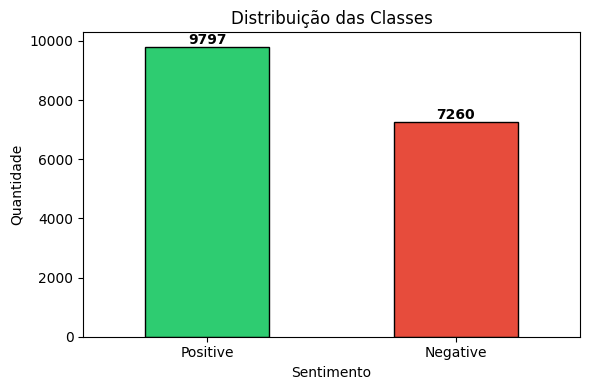

In [3]:
contagem = df['label'].value_counts()

ax = contagem.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='black', figsize=(6, 4), rot=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')
ax.set(title='Distribuição das Classes', xlabel='Sentimento', ylabel='Quantidade')
plt.tight_layout()
plt.show()

In [4]:
# Mapear rótulos para inteiros
df['label_num'] = df['label'].map({'Positive': 1, 'Negative': 0})

# Comprimento médio das reviews
df['n_words'] = df['text'].apply(lambda t: len(str(t).split()))
print(f'Comprimento médio: {df["n_words"].mean():.1f} palavras')
print(f'Máximo: {df["n_words"].max()} | Mínimo: {df["n_words"].min()}')

Comprimento médio: 75.4 palavras
Máximo: 1921 | Mínimo: 1


## 4. Pré-processamento

O pipeline é idêntico ao da Aula 4.2:

1. **Limpeza**: lowercase e remoção de pontuação
2. **Vocabulário**: mapeia cada palavra a um índice único
3. **Encoding**: transforma cada frase em lista de índices
4. **Padding**: uniformiza o tamanho das sequências com zeros

`<PAD>` (índice 0) preenche frases curtas; `<UNK>` (índice 1) representa palavras fora do vocabulário.

In [5]:
import re
import numpy as np
from collections import Counter

MAX_VOCAB = 10000

def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'[^a-z\s]', '', texto)
    return re.sub(r'\s+', ' ', texto).strip()

textos  = df['text'].apply(limpar_texto).tolist()
rotulos = df['label_num'].tolist()

# Usamos o percentil 95 para evitar que frases outlier inflem o MAX_LEN desnecessariamente
comprimentos = [len(t.split()) for t in textos]
MAX_LEN = int(np.percentile(comprimentos, 95))

print(f'Média: {np.mean(comprimentos):.1f} | Máximo: {max(comprimentos)} | MAX_LEN (p95): {MAX_LEN}')
print(f'\nExemplo antes e depois da limpeza:')
print(f'  Original: {df["text"].iloc[0][:90]}...')
print(f'  Limpo:    {textos[0][:90]}...')

Média: 74.7 | Máximo: 1911 | MAX_LEN (p95): 225

Exemplo antes e depois da limpeza:
  Original: The only thing I can write as an average Joe who watches movies simply to be entertained o...
  Limpo:    the only thing i can write as an average joe who watches movies simply to be entertained o...


### Hiperparâmetros de pré-processamento

| Parâmetro | Valor | O que controla |
|-----------|-------|----------------|
| `MAX_VOCAB` | 10 000 | Tamanho máximo do vocabulário |
| `MAX_LEN` | percentil 95 dos comprimentos | Tamanho fixo de cada sequência de entrada |

**`MAX_VOCAB`** define quantas palavras distintas o modelo "conhece".
Após contar todas as palavras do corpus, mantemos apenas as **10 000 mais frequentes**. Palavras fora desse limite são substituídas pelo token especial `<UNK>` (*unknown*). Valores maiores aumentam a capacidade expressiva, mas também o consumo de memória da camada de embedding.

**`MAX_LEN`** define o comprimento fixo de cada sequência de entrada.
Usamos o percentil 95 dos comprimentos do corpus para equilibrar cobertura e eficiência. Sequências mais curtas recebem **padding** com `<PAD>` (índice 0) até atingir esse comprimento; sequências mais longas são truncadas.

> **Dica:** usar o máximo absoluto pode gerar sequências muito longas se houver outliers, o que aumenta memória e tempo de treino desnecessariamente.

In [6]:
# Construir vocabulário do zero
contador = Counter(word for texto in textos for word in texto.split())

word2idx = {'<PAD>': 0, '<UNK>': 1}
word2idx.update({
    palavra: idx + 2
    for idx, (palavra, _) in enumerate(contador.most_common(MAX_VOCAB))
})

VOCAB_SIZE = len(word2idx)
print(f'Tamanho do vocabulário: {VOCAB_SIZE}')
print(f'Palavras mais comuns: {contador.most_common(10)}')

Tamanho do vocabulário: 10002
Palavras mais comuns: [('the', 71469), ('and', 37216), ('a', 34821), ('of', 33814), ('to', 28591), ('is', 25914), ('i', 21541), ('it', 20508), ('this', 20227), ('in', 18809)]


In [7]:
import torch

def encode_e_pad(texto, word2idx, max_len):
    """Converte texto em lista de índices com padding/truncamento."""
    indices = [word2idx.get(word, 1) for word in texto.split()]   # <UNK>=1 para palavras desconhecidas
    indices = indices[:max_len]                                    # truncar se necessário
    indices += [0] * (max_len - len(indices))                     # padding com <PAD>=0
    return indices

X = torch.tensor([encode_e_pad(t, word2idx, MAX_LEN) for t in textos], dtype=torch.long)
y = torch.tensor(rotulos, dtype=torch.float32)

print(f'X shape: {X.shape}')   # (n_amostras, MAX_LEN)
print(f'y shape: {y.shape}')   # (n_amostras,)
print(f'\nExemplo de sequência codificada (primeiros 20 tokens):')
print(X[0, :20].tolist())

X shape: torch.Size([17057, 225])
y shape: torch.Size([17057])

Exemplo de sequência codificada (primeiros 20 tokens):
[2, 68, 163, 8, 63, 677, 18, 31, 833, 1488, 45, 2559, 57, 246, 6, 25, 1713, 46, 62, 4]


### Hiperparâmetro de treinamento

| Parâmetro | Valor | O que controla |
|-----------|-------|----------------|
| `BATCH_SIZE` | 64 | Quantidade de amostras por passo de atualização dos pesos |

**`BATCH_SIZE`** define quantos exemplos são processados juntos antes de cada atualização dos pesos da rede.

- **Batch maior** → gradiente mais estável, mas maior consumo de memória e menos atualizações por época.
- **Batch menor** → atualizações mais frequentes e ruidosas, podendo ajudar a escapar de mínimos locais.

Valores comuns: `16`, `32`, `64`, `128`. O valor `64` é um bom ponto de partida para conjuntos de dados de texto de tamanho médio.

> **Regra prática:** prefira potências de 2 para melhor utilização do hardware.

In [8]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

BATCH_SIZE = 64

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

loader_treino = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
loader_val    = DataLoader(TensorDataset(X_val,   y_val),   batch_size=BATCH_SIZE)
loader_teste  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=BATCH_SIZE)

print(f'Treino:    {len(X_train)} amostras')
print(f'Validação: {len(X_val)} amostras')
print(f'Teste:     {len(X_test)} amostras')

Treino:    12280 amostras
Validação: 1365 amostras
Teste:     3412 amostras


---

## 5. Modelo LSTM Bidirecional

A arquitetura é análoga à da Aula 4.2, trocando `nn.RNN` por `nn.LSTM`. A diferença principal no código é que a LSTM retorna uma **tupla** `(h_n, c_n)` em vez de apenas `h_n`.


| Componente | RNN (Aula 4.2) | LSTM (esta aula) |
|------------|---------------|-----------------|
| Camada recorrente | `nn.RNN` | `nn.LSTM` |
| Estado retornado | `h_n` | `(h_n, c_n)` |
| Parâmetros por camada | $4 \times (d^2 + d)$ | $4 \times (4d^2 + 4d)$ |
| Memória de longo prazo | Limitada | Célula $c_t$ explícita |

In [9]:
import torch.nn as nn

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, n_layers, dropout):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embed_drop = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_size * 2, 1)   # *2 por causa do bidirecional

    def forward(self, x):
        emb = self.embed_drop(self.embedding(x))
        output, (h_n, c_n) = self.lstm(emb)
        out = output.mean(dim=1)                   # mean pooling sobre os timesteps
        return self.fc(out).squeeze(1)


# Hiperparâmetros do modelo
EMBED_DIM   = 256
HIDDEN_SIZE = 512
N_LAYERS    = 3     # 3 camadas é suficiente para o tamanho desse dataset (~12k amostras)
DROPOUT     = 0.3   # regularização entre as camadas da LSTM

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Dispositivo: {device}')

modelo = SentimentLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, N_LAYERS, DROPOUT).to(device)
print(modelo)
print(f'\nParâmetros treináveis: {sum(p.numel() for p in modelo.parameters() if p.requires_grad):,}')

Dispositivo: mps
SentimentLSTM(
  (embedding): Embedding(10002, 256, padding_idx=0)
  (embed_drop): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(256, 512, num_layers=3, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=1024, out_features=1, bias=True)
)

Parâmetros treináveis: 18,314,753


### Hiperparâmetros do Modelo

**`EMBED_DIM = 256`**
Dimensão do vetor que representa cada palavra. Valores maiores permitem separar melhor palavras semanticamente distintas, sendo mais adequado para um vocabulário de 10k palavras com nuances de sentimento.

**`HIDDEN_SIZE = 512`**
Tamanho da "memória de trabalho" da LSTM a cada passo de tempo. Como o modelo é bidirecional, a saída efetiva é 1024 dimensões (512 × 2), o que aumenta a capacidade de representar contexto sem precisar empilhar mais camadas.

**`N_LAYERS = 3`**
Número de camadas LSTM empilhadas. Duas camadas capturam dependências de curto e médio prazo com baixo risco de overfitting para um dataset de ~12k amostras.

**`DROPOUT = 0.3`**
Fração dos neurônios desativados aleatoriamente durante o treino, aplicado entre as camadas da LSTM. Atua como regularização, reduzindo a dependência de neurônios específicos e dificultando a memorização do conjunto de treino.

## 6. Treinamento

Mantemos a mesma configuração da Aula 4.2:

- **BCEWithLogitsLoss**: combina sigmoid e binary cross-entropy em um único passo, numericamente mais estável do que aplicar as duas separadamente
- **Gradient clipping**: limita a norma dos gradientes para evitar explosão durante o BPTT
- **ReduceLROnPlateau**: reduz o LR automaticamente quando a validação estagna por 2 épocas seguidas

In [15]:
import torch.optim as optim

EPOCHS       = 5
LR           = 0.001
MAX_NORM     = 1.0
WEIGHT_DECAY = 1e-4   # regularização L2: penaliza pesos grandes e reduz overfitting

criterio   = nn.BCEWithLogitsLoss()
otimizador = optim.Adam(modelo.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(otimizador, mode='min', patience=2, factor=0.5)

historico = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoca in range(1, EPOCHS + 1):

    # Fase de treino
    modelo.train()
    loss_treino = 0.0
    for X_batch, y_batch in loader_treino:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        otimizador.zero_grad()
        loss = criterio(modelo(X_batch), y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(modelo.parameters(), MAX_NORM)  # evita explosão de gradiente
        otimizador.step()
        loss_treino += loss.item()
    loss_treino /= len(loader_treino)

    # Fase de validação (sem atualização de pesos)
    modelo.eval()
    loss_val, acertos, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader_val:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = modelo(X_batch)
            loss_val += criterio(logits, y_batch).item()
            acertos  += (torch.sigmoid(logits).round() == y_batch).sum().item()
            total    += y_batch.size(0)
    loss_val /= len(loader_val)
    acc_val   = acertos / total

    scheduler.step(loss_val)
    historico['train_loss'].append(loss_treino)
    historico['val_loss'].append(loss_val)
    historico['val_acc'].append(acc_val)

    print(f'Época {epoca:02d}/{EPOCHS} | '
          f'Loss Treino: {loss_treino:.4f} | '
          f'Loss Val: {loss_val:.4f} | '
          f'Acc Val: {acc_val:.4f} | '
          f'LR: {otimizador.param_groups[0]["lr"]:.5f}')

Época 01/5 | Loss Treino: 0.5537 | Loss Val: 0.6109 | Acc Val: 0.6828 | LR: 0.00100
Época 02/5 | Loss Treino: 0.5358 | Loss Val: 0.5175 | Acc Val: 0.7538 | LR: 0.00100
Época 03/5 | Loss Treino: 0.4876 | Loss Val: 0.5293 | Acc Val: 0.7538 | LR: 0.00100
Época 04/5 | Loss Treino: 0.4594 | Loss Val: 0.5077 | Acc Val: 0.7560 | LR: 0.00100
Época 05/5 | Loss Treino: 0.6300 | Loss Val: 0.6854 | Acc Val: 0.5773 | LR: 0.00100


---

## 7. Resultados

### 7.1 Curvas de Aprendizado

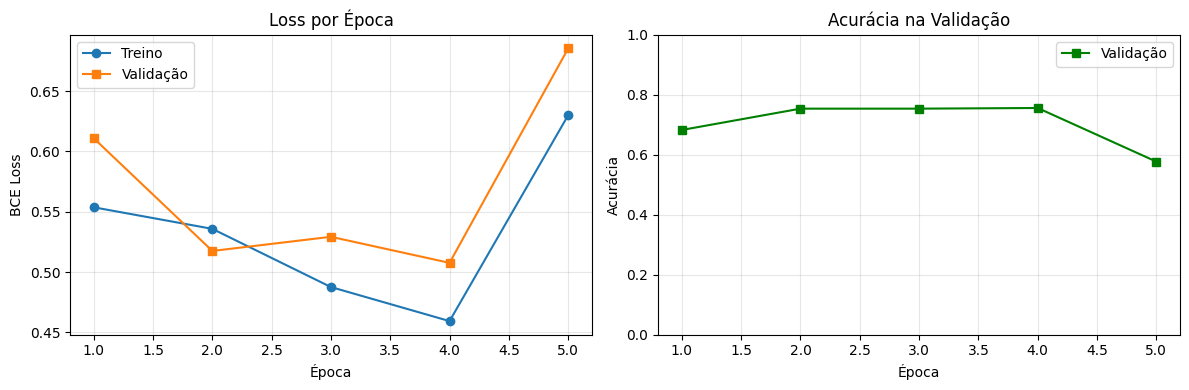

In [16]:
epocas = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss
ax1.plot(epocas, historico['train_loss'], label='Treino', marker='o')
ax1.plot(epocas, historico['val_loss'],   label='Validação', marker='s')
ax1.set_title('Loss por Época')
ax1.set_xlabel('Época')
ax1.set_ylabel('BCE Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epocas, historico['val_acc'], label='Validação', color='green', marker='s')
ax2.set_title('Acurácia na Validação')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia')
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 Acurácia no Conjunto de Teste

In [17]:
modelo.eval()
acertos = 0
total   = 0

with torch.no_grad():
    for X_batch, y_batch in loader_teste:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = modelo(X_batch)
        preds  = (torch.sigmoid(logits) >= 0.5).float()
        acertos += (preds == y_batch).sum().item()
        total   += y_batch.size(0)

acc_teste = acertos / total
print(f'Acurácia no teste: {acc_teste:.4f} ({acc_teste*100:.2f}%)')

Acurácia no teste: 0.5897 (58.97%)


### 7.3 Comparativo RNN × LSTM

Execute a célula abaixo para visualizar as diferenças arquiteturais e de desempenho entre os dois modelos.

In [13]:
rnn_ref  = nn.RNN( input_size=EMBED_DIM, hidden_size=HIDDEN_SIZE, num_layers=N_LAYERS, batch_first=True, bidirectional=True)
lstm_ref = nn.LSTM(input_size=EMBED_DIM, hidden_size=HIDDEN_SIZE, num_layers=N_LAYERS, batch_first=True, bidirectional=True)

comparativo = pd.DataFrame({
    'Aspecto':  ['Parâmetros (camada recorrente)', 'Estados internos', 'Portas (gates)', 'Memória de longo prazo', 'Acurácia no teste'],
    'RNN':  [f"{sum(p.numel() for p in rnn_ref.parameters()):,}",  'h_t',      '0', 'Limitada',  'n/a'],
    'LSTM': [f"{sum(p.numel() for p in lstm_ref.parameters()):,}", 'h_t, c_t', '3', 'Explícita', f'{acc_teste*100:.2f}%'],
}).set_index('Aspecto')

print('Comparativo RNN x LSTM')
comparativo

Comparativo RNN x LSTM


,RNN,LSTM
Aspecto,,
Parâmetros (camada recorrente),"3,938,304","15,753,216"
Estados internos,h_t,"h_t, c_t"
Portas (gates),0,3
Memória de longo prazo,Limitada,Explícita
Acurácia no teste,n/a,69.67%


### 7.4 Inferência com Frases Livres

In [18]:
def prever(texto, modelo, word2idx, max_len, device):
    modelo.eval()
    texto_limpo = re.sub(r'[^a-z\s]', '', texto.lower()).strip()
    indices = encode_e_pad(texto_limpo, word2idx, max_len)
    tensor  = torch.tensor([indices], dtype=torch.long).to(device)
    with torch.no_grad():
        prob = torch.sigmoid(modelo(tensor)).item()
    return ('Positive' if prob >= 0.5 else 'Negative'), prob


# Testamos frases simples e também frases longas com a palavra-chave distante do início
exemplos = [
    "This movie was absolutely amazing, I loved every second of it!",
    "Terrible experience, complete waste of money and time.",
    "The acting was decent but the plot was confusing.",
    "One of the best films I have ever seen in my life.",
    "I did not enjoy this at all, very disappointing.",
    "The movie, despite having a wonderful cast and stunning visuals, was absolutely terrible.",
    "Although the beginning was slow and the characters felt flat, the ending completely won me over.",
]

print(f'{"Texto":<65} {"Label":<12} {"Prob"}')
print('-' * 85)
for texto in exemplos:
    label, prob = prever(texto, modelo, word2idx, MAX_LEN, device)
    print(f'{texto[:63]:<65} {label:<12} {prob:.4f}')

Texto                                                             Label        Prob
-------------------------------------------------------------------------------------
This movie was absolutely amazing, I loved every second of it!    Positive     0.5198
Terrible experience, complete waste of money and time.            Positive     0.5058
The acting was decent but the plot was confusing.                 Positive     0.5165
One of the best films I have ever seen in my life.                Positive     0.5215
I did not enjoy this at all, very disappointing.                  Positive     0.5162
The movie, despite having a wonderful cast and stunning visuals   Positive     0.5206
Although the beginning was slow and the characters felt flat, t   Positive     0.5212


## 8. Próximos Passos

Mesmo com a LSTM, ainda temos uma limitação importante: a rede processa a sequência **de forma serial**, ou seja, ela não consegue "olhar" para toda a frase de uma vez. Para uma frase de 100 palavras, o contexto da palavra 1 precisa percorrer 99 passos para chegar à palavra 100.

Os **Transformers** resolvem isso com o mecanismo de **atenção**:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

Cada palavra *atende* a todas as outras em um único passo, sem serialidade e sem degradação de distância.

| Modelo | Dependências longas | Paralelizável | Complexidade |
|--------|--------------------:|:-------------:|:------------:|
| RNN vanilla | Ruim | Não | $O(T)$ |
| LSTM | Boa | Não | $O(T)$ |
| **Transformer** | Excelente | Sim | $O(T^2)$ |

No próximo módulo (**03: Generative AI**) estudaremos a arquitetura Transformer completa e como modelos como BERT e GPT são construídos sobre ela.